In [21]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer

cancer_data = load_breast_cancer()

df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

df['biopsy_outcome'] = cancer_data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,biopsy_outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [22]:
df.shape

(569, 31)

In [23]:
print(df.biopsy_outcome.value_counts())
print(df.biopsy_outcome.value_counts(normalize=True)*100)

biopsy_outcome
1    357
0    212
Name: count, dtype: int64
biopsy_outcome
1    62.741652
0    37.258348
Name: proportion, dtype: float64


In [24]:
engineered_df = df.copy()

engineered_df['compactness_concavity_ratio'] = engineered_df['mean compactness'] / (engineered_df['mean concavity'] + 1e-5)
engineered_df['radius_texture_product'] = engineered_df['mean radius'] * engineered_df['mean texture']

print("--- FEATURE ENGINEERING COMPLETE ---")
print(f"New Dataset Shape: {engineered_df.shape}")
print("\nVerifying our new engineered features:")
engineered_df[['mean radius', 'mean texture', 'radius_texture_product', 'compactness_concavity_ratio']].head()

--- FEATURE ENGINEERING COMPLETE ---
New Dataset Shape: (569, 33)

Verifying our new engineered features:


,mean radius,mean texture,radius_texture_product,compactness_concavity_ratio
0,17.99,10.38,186.7362,0.924994
1,20.57,17.77,365.5289,0.904844
2,19.69,21.25,418.4125,0.809989
3,11.42,20.38,232.7396,1.176008
4,20.29,14.34,290.9586,0.670673


In [25]:
from sklearn.model_selection import train_test_split

X = engineered_df.drop(columns=['biopsy_outcome'])
y = engineered_df.biopsy_outcome

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("--- STRATIFIED SPLIT COMPLETE ---")
print(f"Training Features Shape: {X_train.shape}")
print(f"Validation Features Shape: {X_valid.shape}")
X.head()

--- STRATIFIED SPLIT COMPLETE ---
Training Features Shape: (455, 32)
Validation Features Shape: (114, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,compactness_concavity_ratio,radius_texture_product
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.924994,186.7362
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.904844,365.5289
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.809989,418.4125
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1.176008,232.7396
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.670673,290.9586


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

tuning_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

parameter_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [3,5,7],
    'model__learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(tuning_pipeline, parameter_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("--- AUTOMATED TUNING COMPLETE ---")
print(f"Absolute Best Hyperparameters Found:\n{grid_search.best_params_}")
print(f"\nBest Cross-Validation ROC-AUC Score: {grid_search.best_score_*100:.2f}%")


--- AUTOMATED TUNING COMPLETE ---
Absolute Best Hyperparameters Found:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}

Best Cross-Validation ROC-AUC Score: 99.18%


In [29]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

prob = grid_search.predict_proba(X_valid)[:, 1]
pred = grid_search.predict(X_valid)


final_auc = roc_auc_score(y_valid, prob)

print(f"--- VALIDATION PREDICTIONS COMPLETE ---")
print(f"Final Validation ROC-AUC Score: {final_auc*100:.2f}%\n")
print("Detailed Clinical Classification Report:")
print(classification_report(y_valid, pred, target_names=['Malignant (0)', 'Benign (1)']))

--- VALIDATION PREDICTIONS COMPLETE ---
Final Validation ROC-AUC Score: 99.17%

Detailed Clinical Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.90      0.90      0.90        42
   Benign (1)       0.94      0.94      0.94        72

     accuracy                           0.93       114
    macro avg       0.92      0.92      0.92       114
 weighted avg       0.93      0.93      0.93       114



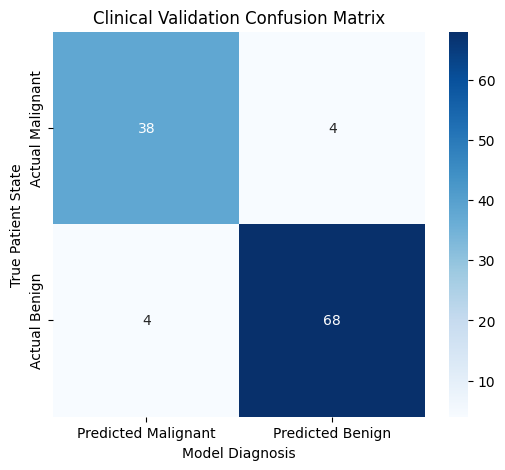

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_valid, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title('Clinical Validation Confusion Matrix')
plt.ylabel('True Patient State')
plt.xlabel('Model Diagnosis')
plt.show()

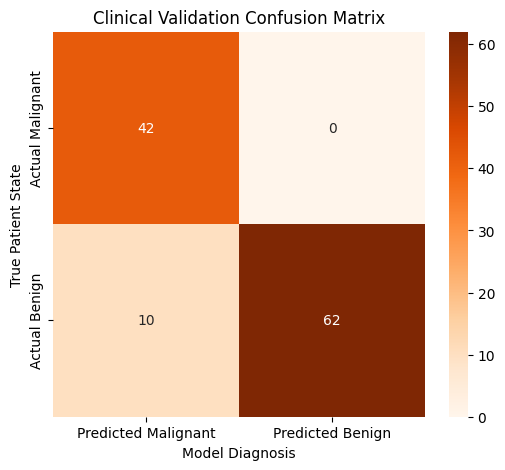

In [49]:
custom_threshold = 0.90
pred_cautious = (prob > custom_threshold).astype(int)

cm_cautious = confusion_matrix(y_valid, pred_cautious)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_cautious, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title('Clinical Validation Confusion Matrix')
plt.ylabel('True Patient State')
plt.xlabel('Model Diagnosis')
plt.show()

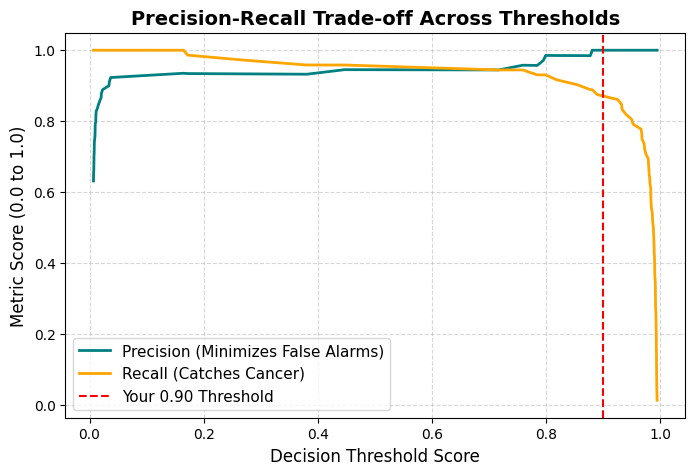

In [47]:
from sklearn.metrics import precision_recall_curve


precisions, recalls, thresholds = precision_recall_curve(y_valid, prob)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision (Minimizes False Alarms)", color="teal", linewidth=2)
plt.plot(thresholds, recalls[:-1], label="Recall (Catches Cancer)", color="orange", linewidth=2)

plt.title("Precision-Recall Trade-off Across Thresholds", fontsize=14, fontweight='bold')
plt.xlabel("Decision Threshold Score", fontsize=12)
plt.ylabel("Metric Score (0.0 to 1.0)", fontsize=12)
plt.axvline(x=0.90, color="red", linestyle="--", label="Your 0.90 Threshold")
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

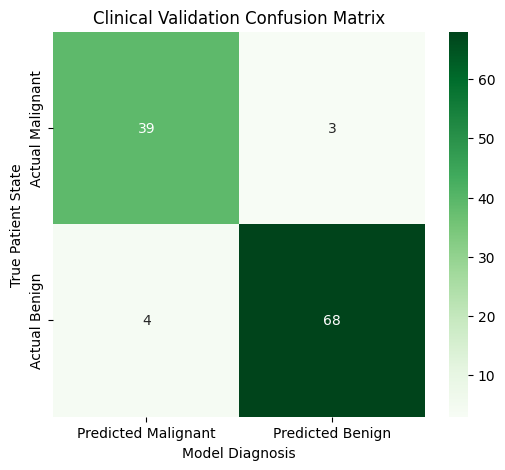

In [54]:
second_threshold = 0.75
pred_cautious2 = (prob > second_threshold).astype(int)

cm_cautious2 = confusion_matrix(y_valid, pred_cautious2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_cautious2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Malignant', 'Predicted Benign'],
            yticklabels=['Actual Malignant', 'Actual Benign'])
plt.title('Clinical Validation Confusion Matrix')
plt.ylabel('True Patient State')
plt.xlabel('Model Diagnosis')
plt.show()

/tmp/ipykernel_6569/4151367997.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


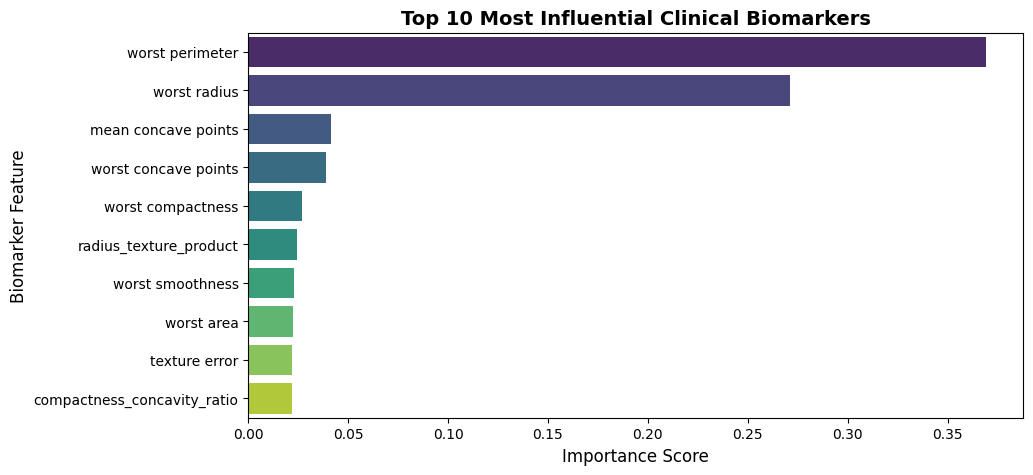

In [50]:
best_model = grid_search.best_estimator_.named_steps['model']

importances = best_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Most Influential Clinical Biomarkers', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Biomarker Feature', fontsize=12)
plt.show()